# Single epoch, base Adam (14-wire depth-8 circuit)

The stripped-down single-epoch question: train plain Adam models of a range
of sizes for **one pass** over a 20% sample of the input space and see what
held-out performance falls out. No noise, no eps tweaks, no arms.

- **14 wires, circuit depth 8**, circuit seed 4, solo **wire 1** — tap
  depth 8, gated in the final layer, all 14 inputs relevant, perfectly
  balanced (verified below). Depth 8 keeps it genuinely hard.
- **20/80 split**: `train_frac=0.2` = a fixed pool of 3277 of the 16384
  inputs; the other 13107 are held out. At `batch=32` one epoch is
  **102 updates**, each on fresh data (the 13-sample remainder is skipped
  until the next epoch's reshuffle).
- 7 shapes x 3 seeds; runs take seconds each.

In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    import os
    %pip -q install -U "jax[cuda12]" optax
    if not os.path.exists("/content/circscale"):
        !git clone https://github.com/amdson/circscale.git /content/circscale
    %cd /content/circscale
    !git pull
    from google.colab import drive
    drive.mount("/content/drive")
    os.makedirs("/content/drive/MyDrive/circscale_runs", exist_ok=True)
    if not os.path.islink("runs"):
        os.symlink("/content/drive/MyDrive/circscale_runs", "runs")

Cloning into '/content/circscale'...
remote: Enumerating objects: 176, done.
remote: Counting objects: 100% (176/176), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 176 (delta 104), reused 120 (delta 54), pack-reused 0 (from 0)
Receiving objects: 100% (176/176), 419.59 KiB | 6.88 MiB/s, done.
Resolving deltas: 100% (104/104), done.
/content/circscale
Already up to date.
Mounted at /content/drive


## The circuit

In [4]:
from itertools import product

import matplotlib.pyplot as plt
import numpy as np

from random_circuit import evaluate_np, sample_circuit
from train import RunConfig, load_run, run

N_WIRES, CIRC_DEPTH, CIRCUIT_SEED, TARGET_WIRES = 14, 8, 4, [2, 3]

circuit = sample_circuit(np.random.default_rng(CIRCUIT_SEED), N_WIRES, CIRC_DEPTH)
X = np.array(list(product([0, 1], repeat=N_WIRES)), dtype=np.uint8)
y = evaluate_np(circuit, X)[:, TARGET_WIRES]
flip = np.eye(N_WIRES, dtype=np.uint8)
powers = 1 << np.arange(N_WIRES)[::-1]
rel = [i for i in range(N_WIRES) if np.any(y != y[(X ^ flip[i]) @ powers])]
print(f"tap depths: {circuit.out_depths}")
print(f"wire {TARGET_WIRES}: depth {circuit.out_depths[TARGET_WIRES]}, "
      f"relevant inputs {len(rel)}/{N_WIRES}, balance {y.mean():.3f}")

tap depths: [6 8 8 5 8 8 8 1 4 5 3 4 6 7]
wire [2, 3]: depth [8 5], relevant inputs 14/14, balance 0.500


## Config

In [5]:
TRAIN_FRAC = 0.2          # pool of 3277 of the 16384 inputs (pool_seed 0)
BATCH = 32
EPOCH_STEPS = int(round(TRAIN_FRAC * 2 ** N_WIRES)) // BATCH   # 102
SEEDS = [0, 1, 2]
OUT_DIR = "runs/ep14"
CHANCE = float(np.log(2))

# (width, mlp_depth, lr) — Adam LRs tuned at batch 256 (runs/lr_table.json)
SHAPES = [
    (32,  2, 1e-2),
    (64,  3, 1e-2),
    (128, 4, 3e-3),
    (180, 5, 3e-3),
    (256, 6, 1e-3),
    (360, 7, 1e-3),
    (512, 8, 1e-3),
]


def ep_cfg(width, depth, lr, epochs=1, **kw):
    return RunConfig(width=width, mlp_depth=depth, lr=lr, warmup=0,
                     batch=BATCH, steps=epochs * EPOCH_STEPS, eval_every=1,
                     n_wires=N_WIRES, circ_depth=CIRC_DEPTH,
                     circuit_seed=CIRCUIT_SEED, output_wires=(TARGET_WIRE,),
                     train_frac=TRAIN_FRAC, data_order="epoch",
                     out_dir=OUT_DIR, **kw)


def n_params(w, d, hr=4):
    h = hr * w
    return N_WIRES * w + d * (w + w * h + h * w) + w + w * N_WIRES


def final(d, key="per_out_acc_ho"):
    return d[key][-1, TARGET_WIRE]


print(f"one epoch = {EPOCH_STEPS} steps of batch {BATCH} "
      f"({EPOCH_STEPS * BATCH} samples seen)")

one epoch = 102 steps of batch 32 (3264 samples seen)


## LR check (w128d4, one epoch)

The tuned LRs come from batch-256 runs; sanity-check the neighborhood at
batch 32 before trusting the sweep.

In [ ]:
for lr in (1e-3, 3e-3, 1e-2):
    accs = []
    for s in SEEDS:
        cfg = ep_cfg(128, 4, lr, model_seed=s)
        run(cfg, quiet=True)
        accs.append(final(load_run(cfg.npz_path)[1]))
    print(f"lr={lr:g}: final held-out acc {np.mean(accs):.3f} "
          f"(seeds: {' '.join(f'{a:.3f}' for a in accs)})")

## Single-epoch sweep: 7 shapes x 3 seeds (idempotent)

In [5]:
sweep = {}
for w, d, lr in SHAPES:
    for s in SEEDS:
        cfg = ep_cfg(w, d, lr, model_seed=s)
        run(cfg, quiet=False)
        sweep[(w, d, s)] = load_run(cfg.npz_path)[1]
print(f"{len(sweep)} runs done")

21 runs done


## Trajectories and scaling

Seven panels: BCE on wire 1 over the single pass (thin lines = seeds;
solid = held-out, dashed = train pool; x = samples seen, every batch is
unseen data). Last panel: final held-out accuracy vs params.

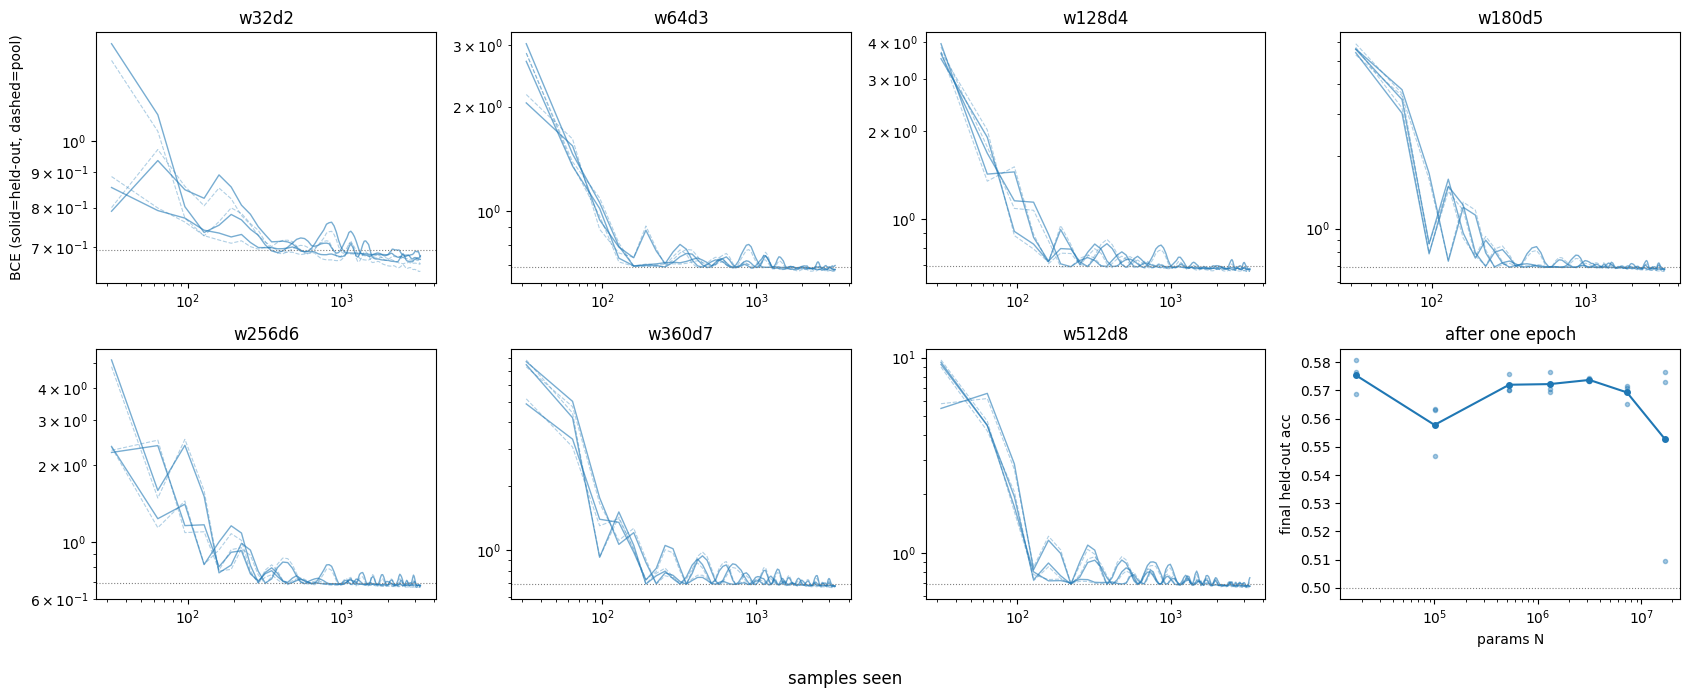

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7), sharex=False, sharey=False)
for ax, (w, d, lr) in zip(axes.flat, SHAPES):
    for s in SEEDS:
        r = sweep[(w, d, s)]
        m = r["eval_steps"] > 0
        ax.plot(r["eval_steps"][m] * BATCH,
                np.maximum(r["per_out_loss_ho"][m][:, TARGET_WIRE], 1e-6),
                color="C0", lw=1.0, alpha=0.6)
        ax.plot(r["eval_steps"][m] * BATCH,
                np.maximum(r["per_out_loss_tr"][m][:, TARGET_WIRE], 1e-6),
                color="C0", lw=0.8, alpha=0.35, ls="--")
    ax.axhline(CHANCE, color="gray", ls=":", lw=0.8)
    ax.set(xscale="log", yscale="log", title=f"w{w}d{d}")
axes.flat[0].set(ylabel="BCE (solid=held-out, dashed=pool)")

ax = axes.flat[7]
Ns = [n_params(w, d) for w, d, lr in SHAPES]
for (w, d, lr), N in zip(SHAPES, Ns):
    ax.plot([N] * len(SEEDS), [final(sweep[(w, d, s)]) for s in SEEDS],
            "o", color="C0", ms=3, alpha=0.4)
ax.plot(Ns, [np.mean([final(sweep[(w, d, s)]) for s in SEEDS])
             for w, d, lr in SHAPES], "-o", color="C0", ms=4)
ax.axhline(0.5, color="gray", ls=":", lw=0.8)
ax.set(xscale="log", xlabel="params N", ylabel="final held-out acc",
       title="after one epoch")
fig.supxlabel("samples seen")
plt.tight_layout()

## Notes

- One epoch at batch 32 = 102 updates; the train-pool vs held-out gap
  (dashed vs solid) can only come from the pool being a fixed 20% sample,
  not from repetition — no sample is ever repeated.
- Depth-8 tap on 14 wires is hard: chance is BCE ln 2 / acc 0.5, and 102
  updates may not move far off it. That's the point — this is the floor
  that seeing-data-once buys, before any repetition or regularization.
- Easy extensions once the base picture is in: `epochs=` in `ep_cfg` for a
  repetition dial, `weight_noise=0.5, adam_eps=1e-4` for the recipe arm.
- LRs are batch-256 tuned; rerun the LR-check cell if a shape's curves look
  pathological. Runs are seconds each; JIT dominates wall time.